In [95]:
import yfinance as yf
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

def normalize_vector(a, b, c):
    x = math.sqrt(a**2 + b**2 + c**2)
    if x == 0:
        return (0, 0, 0)
    return (a/x, b/x, c/x)

print("Pobieranie danych z Yahoo Finance")
data = yf.download("AAPL", period="7d", interval="2m")

vectorized_data = []

for open_, high, low, close in data[['Open', 'High', 'Low', 'Close']].itertuples(index=False, name=None):
    if high == low:
        continue

    if open_ > close:
        x1 = (high - open_) / (high - low)
        x2 = (open_ - close) / (high - low)
        x3 = (close - low) / (high - low)
    else:
        x1 = (high - close) / (high - low)
        x2 = (close - open_) / (high - low)
        x3 = (open_ - low) / (high - low)

    vectorized_data.append(normalize_vector(x1, x2, x3))

print(f"Pobrano i wektoryzowano: {len(vectorized_data)} świec.")

Pobieranie danych z Yahoo Finance


/tmp/ipykernel_2470/867846436.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="7d", interval="2m")
[*********************100%***********************]  1 of 1 completed

Pobrano i wektoryzowano: 1365 świec.


In [96]:
class KohonenSOM:
    def __init__(self, rows=10, cols=10, eta=0.01, h=0.5):
        self.rows = rows
        self.cols = cols
        self.eta = eta
        self.h = h
        self.grid = self._create_board()

    def _create_board(self):
        array = []
        for i in range(self.rows):
            row = []
            for j in range(self.cols):
                w1, w2, w3 = random.uniform(0, 1), random.uniform(0, 1), random.uniform(0, 1)
                row.append(np.array(normalize_vector(w1, w2, w3)))
            array.append(row)
        return array

    def _get_cross(self, r, c):
        all_neurons = [(r, c)]
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.rows and 0 <= nc < self.cols:
                all_neurons.append((nr, nc))
        return all_neurons

    def _update_weights(self, cross_list, current_learned_vector):
        for idx, (neuron_r, neuron_c) in enumerate(cross_list):
            weaken = 1 if idx == 0 else self.h
            old_weight = self.grid[neuron_r][neuron_c]

            new_weight_raw = old_weight + self.eta * weaken * (np.array(current_learned_vector) - old_weight)

            a, b, c = new_weight_raw
            self.grid[neuron_r][neuron_c] = np.array(normalize_vector(a, b, c))

    def train(self, data, epochs=50):
        print("Rozpoczto nauke sieci")
        for epoch in range(epochs):
            for vector in data:
                highest_score = -1
                best_r, best_c = -1, -1

                for r, row in enumerate(self.grid):
                    for c, neuron in enumerate(row):
                        scalar = np.dot(vector, neuron)
                        if highest_score < scalar:
                            highest_score = scalar
                            best_r, best_c = r, c

                if highest_score > -1:
                    cross_list = self._get_cross(best_r, best_c)
                    self._update_weights(cross_list, vector)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoka {epoch}/{epochs} zakonczona.")

        print("Zakonczono uczenie")

    def show_grid(self, title="Mapa Kohonena (RGB = Wagi Świec)"):
        grid_array = np.array(self.grid)
        plt.figure(figsize=(8, 8))
        plt.title(title)
        plt.imshow(grid_array)
        plt.axis('off')
        plt.show()

Rozpoczto nauke sieci
Epoka 0/50 zakonczona.
Epoka 10/50 zakonczona.
Epoka 20/50 zakonczona.
Epoka 30/50 zakonczona.
Epoka 40/50 zakonczona.
Epoka 49/50 zakonczona.
Zakonczono uczenie


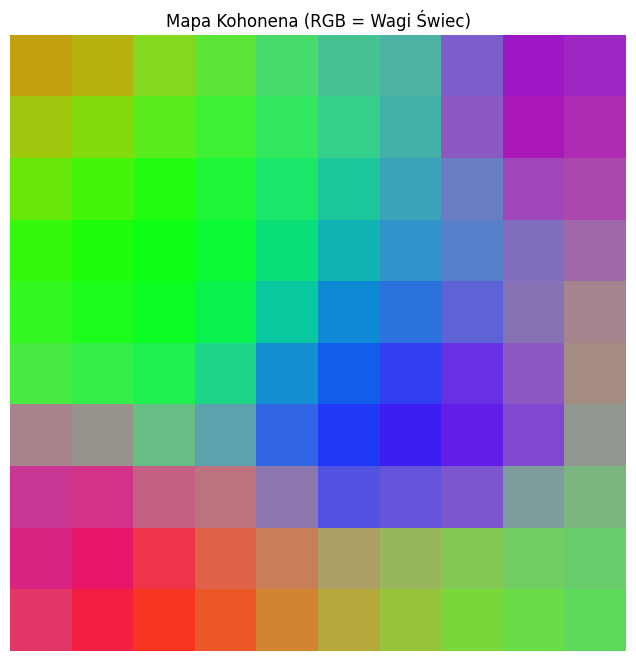

In [97]:
som_network = KohonenSOM(rows=10, cols=10, eta=0.01, h=0.5)

# Odpalamy trening
som_network.train(vectorized_data, epochs=50)

# Wizualizacja
som_network.show_grid()